<a href="https://colab.research.google.com/github/aymanmis/DataSearch-Dashboard/blob/main/E_Scooter_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project explores data collected from a smart E-scooter sharing system deployed in a major metropolitan city. The dataset contains detailed usage logs spanning a full calendar year (2030), providing insight into user behavior, system usage patterns, and operational dynamics.
<br>
<br>
**Dataset Description**
<br>
<br>
Each row in the dataset represents a single scooter trip, with the following key fields:

`StartTime`: The timestamp when a ride started.

`ReturnTime`: The timestamp when the ride ended.

`UsageDuration`: Total duration of the ride (in seconds).

`PickupHub`: The location (hub) where the ride started.

`DropoffHub`: The location where the ride ended.

`PickupHubID` / `DropoffHubID`: Numeric identifiers for hub locations.

`UnitID`: The unique ID of the E-scooter used.

`AccessTier`: The user type – either Subscriber or Customer.

<br>

Additional derived columns:

`DayOfWeek`: Name of the day the ride started.

`Hour`: Hour of day when the ride began.

`Month`: Numeric month of the ride.

`Season`: Season of the year, derived from the ride date.

`IsWeekend`: Whether the trip occurred on a weekend.
<br>
<br>
<br>



In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Download Lato font
!wget -q https://github.com/google/fonts/raw/main/ofl/lato/Lato-Regular.ttf -O Lato-Regular.ttf

In [3]:
## Stylize Matplotlib

# Load Lato font
import matplotlib.font_manager as fm
fm.fontManager.addfont("Lato-Regular.ttf")

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Increase font sizes for titles, labels, ticks, ...
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,

    # Grid and ticks
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    # Style and padding
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1,

    # Line and marker aesthetics
    'lines.linewidth': 2,
    'lines.markersize': 6,

    # Font
    'font.family': 'Lato'
})

# Set consistent color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=sns.color_palette("pastel"))

# White background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [4]:
# Set base theme with larger font
sns.set_theme(style='whitegrid', palette='pastel', font_scale=1.2)

# Refine grid and spine appearance
sns.set_style("whitegrid", {
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
    'grid.color': '#cccccc',
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out'
})

# Optional: override default Seaborn palette globally
custom_palette = sns.color_palette("Set2")  # or "pastel", "muted", etc.
sns.set_palette(custom_palette)

# Consistent figure size (optional if you're setting plt.rcParams elsewhere)
plt.rcParams['figure.figsize'] = (10, 6)

# Optional: better text rendering
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

In [5]:
!pip install gdown

# Data Loading

In [6]:
import gdown
import pandas as pd

# Replace with your file ID
file_id = "1DEjLKwzFIYZIcn67bjM2DujpwVeQ34M_"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "mydata.csv", quiet=False)

# Then read the file normally
df = pd.read_csv("mydata.csv")
df.head()


Downloading...
From (original): https://drive.google.com/uc?id=1DEjLKwzFIYZIcn67bjM2DujpwVeQ34M_
From (redirected): https://drive.google.com/uc?id=1DEjLKwzFIYZIcn67bjM2DujpwVeQ34M_&confirm=t&uuid=c277ffcc-2279-4b9c-945a-1b22f8205e5f
To: /content/mydata.csv
100%|██████████| 418M/418M [00:04<00:00, 85.9MB/s]


,UsageDuration,StartTime,ReturnTime,PickupHubID,PickupHub,DropoffHubID,DropoffHub,UnitID,AccessTier
0,230,2030-01-01 00:04:48,2030-01-01 00:08:39,31203,14th & Rhode Island Ave NW,31200,Massachusetts Ave & Dupont Circle NW,E00141,Subscriber
1,1549,2030-01-01 00:06:37,2030-01-01 00:32:27,31321,15th St & Constitution Ave NW,31114,18th St & Wyoming Ave NW,W24067,Customer
2,177,2030-01-01 00:08:46,2030-01-01 00:11:44,31104,Adams Mill & Columbia Rd NW,31323,Woodley Park Metro / Calvert St & Connecticut ...,W22654,Customer
3,228,2030-01-01 00:08:47,2030-01-01 00:12:35,31281,8th & O St NW,31280,11th & S St NW,W22336,Subscriber
4,1300,2030-01-01 00:12:29,2030-01-01 00:34:10,31014,Lynn & 19th St North,31923,Columbia Pike & S Taylor St,70004,Subscriber


## Data Cleaning & Preprocessing

In [7]:
# Show DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3398417 entries, 0 to 3398416
Data columns (total 9 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   UsageDuration  int64 
 1   StartTime      object
 2   ReturnTime     object
 3   PickupHubID    int64 
 4   PickupHub      object
 5   DropoffHubID   int64 
 6   DropoffHub     object
 7   UnitID         object
 8   AccessTier     object
dtypes: int64(3), object(6)
memory usage: 233.4+ MB


In [8]:
# Convert AccessTier into category
df['AccessTier'] = df['AccessTier'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3398417 entries, 0 to 3398416
Data columns (total 9 columns):
 #   Column         Dtype   
---  ------         -----   
 0   UsageDuration  int64   
 1   StartTime      object  
 2   ReturnTime     object  
 3   PickupHubID    int64   
 4   PickupHub      object  
 5   DropoffHubID   int64   
 6   DropoffHub     object  
 7   UnitID         object  
 8   AccessTier     category
dtypes: category(1), int64(3), object(5)
memory usage: 210.7+ MB


In [9]:
# Convert StartTime and ReturnTime into datetime
df['StartTime'] = pd.to_datetime(df['StartTime'])
df['ReturnTime'] = pd.to_datetime(df['ReturnTime'])

In [10]:
# Show the number of missing values in each column
df.isnull().sum()

,0
UsageDuration,0
StartTime,0
ReturnTime,0
PickupHubID,0
PickupHub,0
DropoffHubID,0
DropoffHub,0
UnitID,14
AccessTier,0


In [11]:
# Drop rows with missing UnitID values (14 rows out of 3.4M — negligible)
df.dropna(subset=['UnitID'], inplace=True)

In [12]:
# Show summary statistics of UsageDuration column
df['UsageDuration'].describe()

,UsageDuration
count,3.398403e+06
mean,1.069698e+03
std,2.205489e+03
min,6.000000e+01
25%,3.960000e+02
50%,6.800000e+02
75%,1.152000e+03
max,8.636500e+04


In [13]:
# Detect and clip outliers in UsageDuration
Q1 = df['UsageDuration'].quantile(0.25)
Q3 = df['UsageDuration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Outliers found: {len(df[(df['UsageDuration'] < lower_bound) | (df['UsageDuration'] > upper_bound)])}")

df['UsageDuration'] = df['UsageDuration'].clip(lower=lower_bound, upper=upper_bound)

Lower Bound: -738.0
Upper Bound: 2286.0
Outliers found: 226390


In [14]:
# Show summary statistics of UsageDurationCapped column
print(df['UsageDuration'].describe())

count    3.398403e+06
mean     8.522178e+02
std      5.935087e+02
min      6.000000e+01
25%      3.960000e+02
50%      6.800000e+02
75%      1.152000e+03
max      2.286000e+03
Name: UsageDuration, dtype: float64


In [15]:
# Derive time-based features from StartTime
df['DayOfWeek'] = df['StartTime'].dt.day_name()
df['Hour'] = df['StartTime'].dt.hour
df['Month'] = df['StartTime'].dt.month
df['IsWeekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday'])

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

## Exploratory Data Analysis

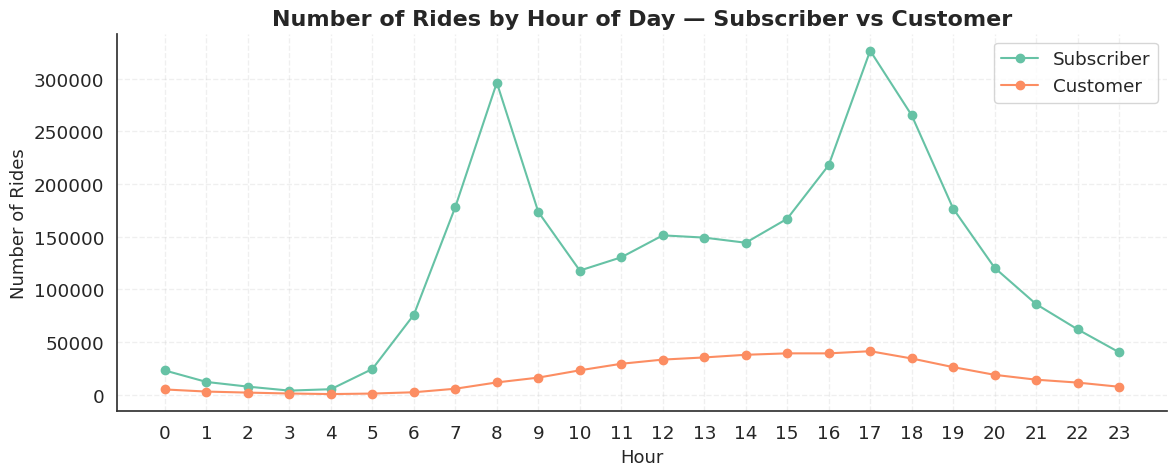

In [16]:
# Rides by hour of day split by access tier
hourly_tier = df.groupby(['Hour', 'AccessTier'], observed=True).size().unstack()

plt.figure(figsize=(12, 5))
plt.plot(hourly_tier.index, hourly_tier['Subscriber'], marker='o', label='Subscriber')
plt.plot(hourly_tier.index, hourly_tier['Customer'], marker='o', label='Customer')
plt.title('Number of Rides by Hour of Day — Subscriber vs Customer')
plt.xlabel('Hour')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

**Key Finding:** Two clear peaks at 8AM and 5PM confirm commuter-driven usage.
Activity drops significantly between 10PM and 5AM.
This suggests time-based pricing could be applied during peak hours.

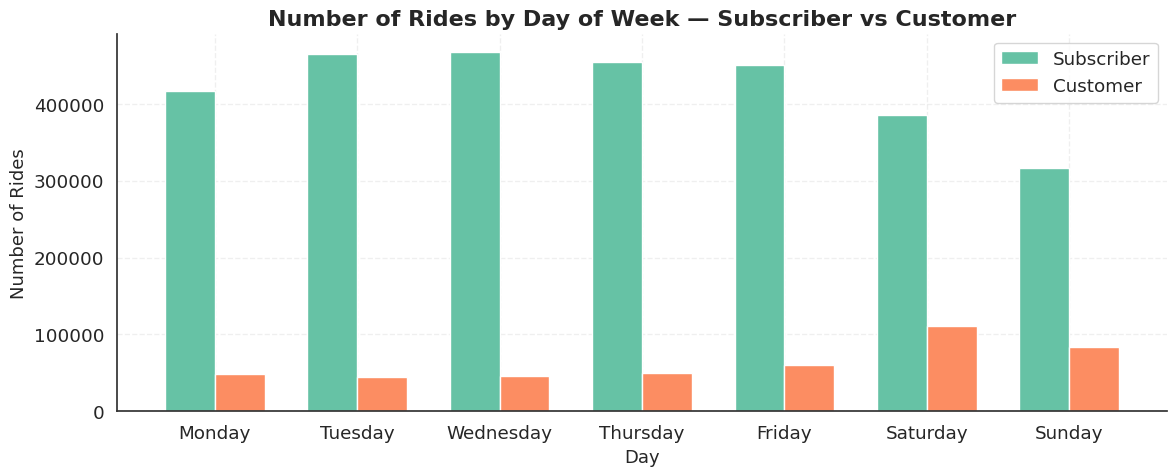

In [17]:
# Rides by day of week split by access tier
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_tier = df.groupby(['DayOfWeek', 'AccessTier'], observed=True).size().unstack().reindex(day_order)

x = range(len(day_order))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], daily_tier['Subscriber'], width=width, label='Subscriber')
plt.bar([i + width/2 for i in x], daily_tier['Customer'], width=width, label='Customer')
plt.title('Number of Rides by Day of Week — Subscriber vs Customer')
plt.xlabel('Day')
plt.ylabel('Number of Rides')
plt.xticks(x, day_order)
plt.legend()
plt.tight_layout()
plt.show()

**Key Finding:** Subscribers outnumber Customers by roughly 8:1 on weekdays, confirming the platform is commuter-driven.
Customer rides increase significantly on Saturday and Sunday, suggesting they are leisure/tourist users.
This gap represents a conversion opportunity — targeting Customers who ride regularly on weekends with a discounted subscription offer.

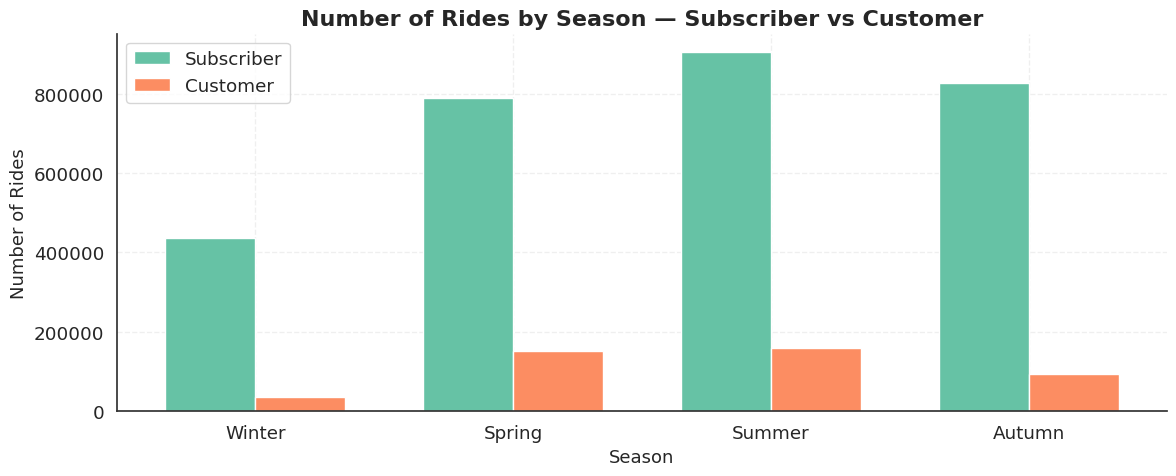

In [18]:
# Rides by season split by access tier
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal_tier = df.groupby(['Season', 'AccessTier'], observed=True).size().unstack().reindex(season_order)

x = range(len(season_order))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], seasonal_tier['Subscriber'], width=width, label='Subscriber')
plt.bar([i + width/2 for i in x], seasonal_tier['Customer'], width=width, label='Customer')
plt.title('Number of Rides by Season — Subscriber vs Customer')
plt.xlabel('Season')
plt.ylabel('Number of Rides')
plt.xticks(x, season_order)
plt.legend()
plt.tight_layout()
plt.show()

**Key Finding:** Summer is the peak season for both tiers, with Winter being the lowest.
Customer rides drop dramatically in Winter — casual riders are highly weather-sensitive.
Subscribers remain active year-round, reinforcing their commuter profile.
Fleet capacity should be increased in Spring and Summer, and reduced in Winter to cut operational costs.

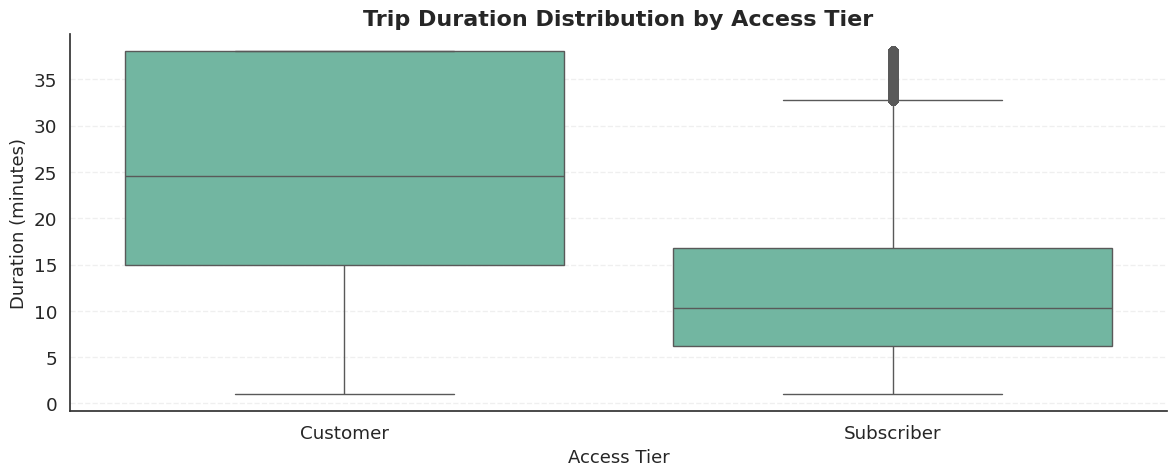

In [19]:
# Trip Duration Distribution by Access Tier

df['UsageDuration_min'] = df['UsageDuration'] / 60

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='AccessTier', y='UsageDuration_min')
plt.title('Trip Duration Distribution by Access Tier')
plt.xlabel('Access Tier')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

**Key Finding:** Customers take significantly longer trips (median ~1500s, ~25 min) compared to Subscribers (median ~650s, ~11 min).
Subscribers make short, focused commuter trips while Customers use scooters for longer leisure rides.
This suggests different pricing models — Subscribers benefit from flat rate plans, Customers from per-minute pricing.

In [20]:
# Hub Pickup vs Dropoff Balance

pickups = df.groupby('PickupHub').size().rename('Pickups')
dropoffs = df.groupby('DropoffHub').size().rename('Dropoffs')

hub_balance = pd.concat([pickups, dropoffs], axis=1).fillna(0)
hub_balance['Imbalance'] = hub_balance['Pickups'] - hub_balance['Dropoffs']
hub_balance['AbsImbalance'] = hub_balance['Imbalance'].abs()
hub_balance = hub_balance.sort_values('AbsImbalance', ascending=False)

print(hub_balance.head(10))

                                      Pickups  Dropoffs  Imbalance  \
14th & Irving St NW                     34900   19031.0    15869.0   
16th & Harvard St NW                    23327    8652.0    14675.0   
17th & K St NW / Farragut Square        14084   23909.0    -9825.0   
13th St & New York Ave NW               10805   20026.0    -9221.0   
Georgetown Harbor / 30th St NW          11799   20029.0    -8230.0   
Massachusetts Ave & Dupont Circle NW    29355   35810.0    -6455.0   
Metro Center / 12th & G St NW           19295   25190.0    -5895.0   
Columbia Rd & Belmont St NW             13195    7474.0     5721.0   
11th & Kenyon St NW                     13700    8038.0     5662.0   
15th & Euclid St  NW                    14276    8656.0     5620.0   

                                      AbsImbalance  
14th & Irving St NW                        15869.0  
16th & Harvard St NW                       14675.0  
17th & K St NW / Farragut Square            9825.0  
13th St & New Yor

In [21]:
# Hub Flow Classification

def classify_hub(imbalance, threshold=1000):
    if imbalance > threshold:
        return 'Supply Source'
    elif imbalance < -threshold:
        return 'Supply Sink'
    else:
        return 'Balanced'

hub_balance = hub_balance.sort_values('AbsImbalance', ascending=False)
hub_balance['Classification'] = hub_balance['Imbalance'].apply(classify_hub)

print(hub_balance['Classification'].value_counts())
print()
print(hub_balance[['Pickups','Dropoffs','Imbalance','Classification']].head(10))

Classification
Balanced         515
Supply Sink       72
Supply Source     64
Name: count, dtype: int64

                                      Pickups  Dropoffs  Imbalance  \
14th & Irving St NW                     34900   19031.0    15869.0   
16th & Harvard St NW                    23327    8652.0    14675.0   
17th & K St NW / Farragut Square        14084   23909.0    -9825.0   
13th St & New York Ave NW               10805   20026.0    -9221.0   
Georgetown Harbor / 30th St NW          11799   20029.0    -8230.0   
Massachusetts Ave & Dupont Circle NW    29355   35810.0    -6455.0   
Metro Center / 12th & G St NW           19295   25190.0    -5895.0   
Columbia Rd & Belmont St NW             13195    7474.0     5721.0   
11th & Kenyon St NW                     13700    8038.0     5662.0   
15th & Euclid St  NW                    14276    8656.0     5620.0   

                                     Classification  
14th & Irving St NW                   Supply Source  
16th & Harvard S

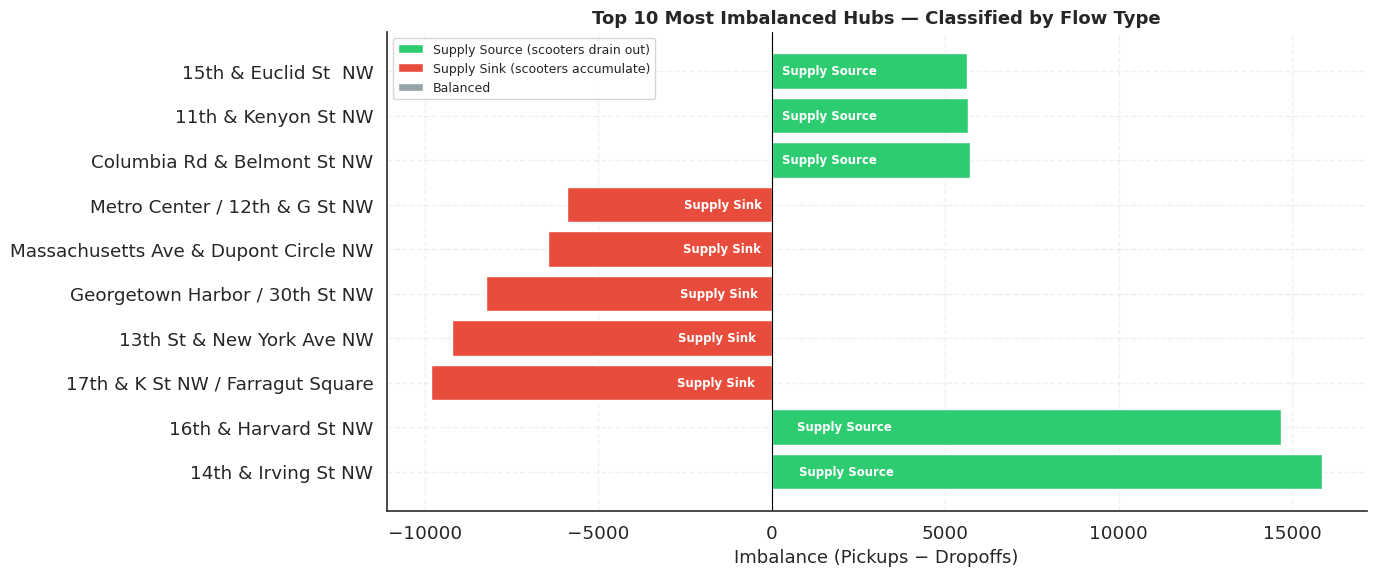

In [22]:
# Top 10 Imbalanced Hubs by Flow Type

top_imbalance = hub_balance.sort_values('AbsImbalance', ascending=False).head(10).copy()

color_map = {
    'Supply Source': '#2ecc71',
    'Supply Sink':   '#e74c3c',
    'Balanced':      '#95a5a6'
}
colors = top_imbalance['Classification'].map(color_map)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top_imbalance.index, top_imbalance['Imbalance'], color=colors)

for bar, (_, row) in zip(bars, top_imbalance.iterrows()):
    width = bar.get_width()
    if width > 0:
        x_pos = width * 0.05
        ha = 'left'
    else:
        x_pos = width * 0.05
        ha = 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            row['Classification'], va='center', ha=ha,
            fontsize=8.5, fontweight='bold', color='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Imbalance (Pickups − Dropoffs)')
ax.set_title('Top 10 Most Imbalanced Hubs — Classified by Flow Type',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Supply Source (scooters drain out)'),
                   Patch(facecolor='#e74c3c', label='Supply Sink (scooters accumulate)'),
                   Patch(facecolor='#95a5a6', label='Balanced')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## Key Findings

The top 10 most imbalanced hubs split clearly into two groups:

**Supply Sources (green)** — 14th & Irving St and 16th & Harvard St show the largest imbalances (+15,869 and +14,675), meaning scooters drain out faster than they return. These hubs require frequent restocking throughout the day.

**Supply Sinks (red)** — 17th & K St / Farragut Square and 13th St & New York Ave absorb the most scooters (−9,825 and −9,221). Scooters accumulate here and need to be redistributed to sources regularly.

The geographic pattern is notable: sources tend to be residential neighborhoods while sinks cluster around commercial and transit corridors — a pattern consistent with commuter behavior explored in the sections below.

In [23]:
# Hourly Imbalance per Hub

top10_hubs = hub_balance.sort_values('AbsImbalance', ascending=False).head(10).index.tolist()

pickups_h  = df.groupby(['PickupHub',  'Hour']).size().reset_index(name='Pickups')
dropoffs_h = df.groupby(['DropoffHub', 'Hour']).size().reset_index(name='Dropoffs')

hourly = pickups_h.merge(
    dropoffs_h,
    left_on=['PickupHub', 'Hour'],
    right_on=['DropoffHub', 'Hour'],
    how='outer'
).fillna(0)

hourly['Hub'] = hourly['PickupHub'].combine_first(hourly['DropoffHub'])
hourly['HourlyImbalance'] = hourly['Pickups'] - hourly['Dropoffs']

hourly_top10 = hourly[hourly['Hub'].isin(top10_hubs)].copy()

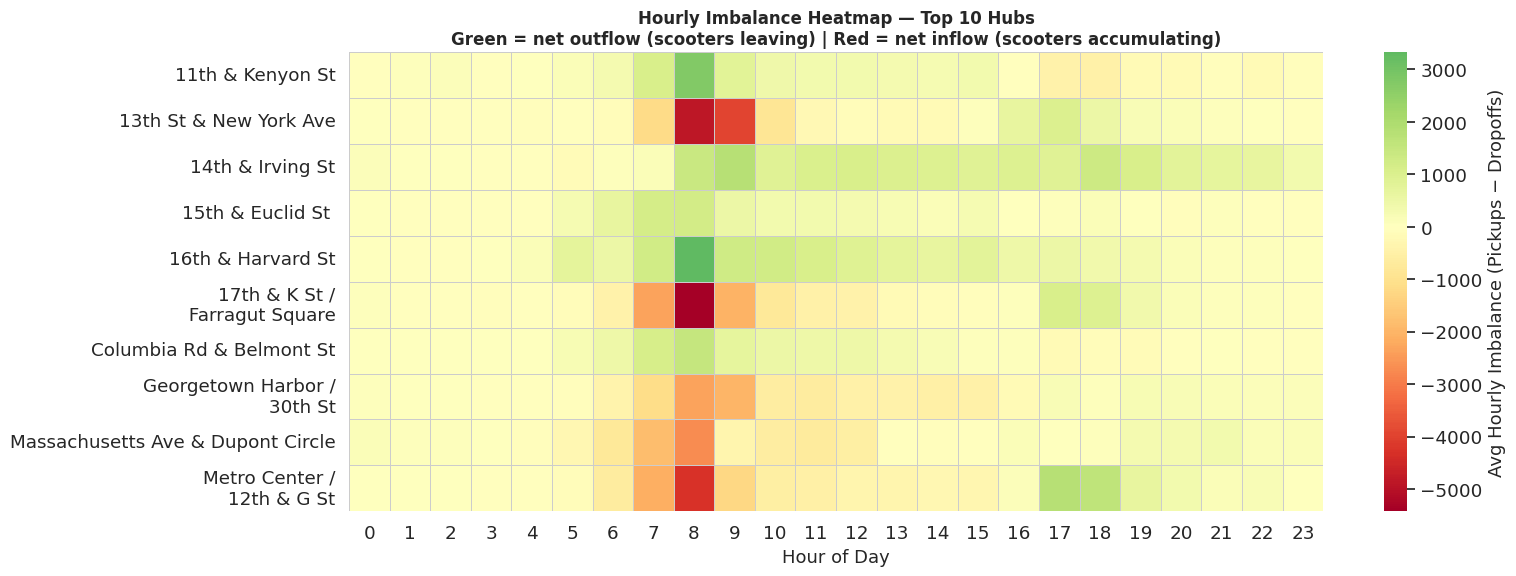

In [24]:
# Hourly Imbalance Heatmap — Top 10 Hubs

pivot = hourly_top10.pivot_table(
    index='Hub', columns='Hour', values='HourlyImbalance', aggfunc='mean'
)

pivot.index = pivot.index.str.replace(' NW', '').str.replace('/', '/\n')

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot,
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    linecolor='#cccccc',
    annot=False,
    ax=ax,
    cbar_kws={'label': 'Avg Hourly Imbalance (Pickups − Dropoffs)'}
)

ax.set_title('Hourly Imbalance Heatmap — Top 10 Hubs\n'
             'Green = net outflow (scooters leaving) | Red = net inflow (scooters accumulating)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Key Findings

The heatmap reveals that hub imbalance is not constant — it is highly concentrated in the **7–9 AM window**, with a secondary pattern emerging around **17–18h**.

**Business district sinks** (17th & K St, Metro Center, Massachusetts Ave) turn deep red at 8 AM — scooters flood in as commuters arrive, making these the highest-priority hubs for morning redistribution before 7 AM.

**Residential sources** (14th & Irving, 16th & Harvard, 15th & Euclid) show green in the morning as commuters ride out, then gradually recover through the afternoon.

**Metro Center** shows an interesting reversal — a strong red at 8 AM followed by green at 17–18h, the clearest business district commuter pattern in the dataset.

Outside of commute hours (10 AM – 4 PM and after 20h), nearly all hubs return to neutral, suggesting that **rebalancing operations can be focused in two 2-hour windows**: early morning (5–7 AM) and mid-afternoon (14–16h) before the evening spike.

In [25]:
# Hub Commuter Flow Profile

morning = (hourly_top10[hourly_top10['Hour'].between(6, 10)]
           .groupby('Hub')['HourlyImbalance'].mean())

evening = (hourly_top10[hourly_top10['Hour'].between(16, 20)]
           .groupby('Hub')['HourlyImbalance'].mean())

flow_profile = pd.DataFrame({'Morning_Imbalance': morning, 'Evening_Imbalance': evening})

def hub_profile(row):
    if row['Morning_Imbalance'] > 0 and row['Evening_Imbalance'] < 0:
        return 'Residential — Outflow AM, Inflow PM'
    elif row['Morning_Imbalance'] < 0 and row['Evening_Imbalance'] > 0:
        return 'Business District — Inflow AM, Outflow PM'
    elif row['Morning_Imbalance'] > 0 and row['Evening_Imbalance'] > 0:
        return 'Persistent Source — drains all day'
    else:
        return 'Persistent Sink — accumulates all day'

flow_profile['HubType'] = flow_profile.apply(hub_profile, axis=1)

print(flow_profile[['Morning_Imbalance', 'Evening_Imbalance', 'HubType']].to_string())

                                      Morning_Imbalance  Evening_Imbalance                                    HubType
Hub                                                                                                                  
11th & Kenyon St NW                              1080.0             -271.0        Residential — Outflow AM, Inflow PM
13th St & New York Ave NW                       -2201.0              496.2  Business District — Inflow AM, Outflow PM
14th & Irving St NW                               856.8             1003.8         Persistent Source — drains all day
15th & Euclid St  NW                              770.2               22.0         Persistent Source — drains all day
16th & Harvard St NW                             1517.8              365.2         Persistent Source — drains all day
17th & K St NW / Farragut Square                -2217.4              522.2  Business District — Inflow AM, Outflow PM
Columbia Rd & Belmont St NW                       853.2 

In [26]:
# Rebalancing Priority Score

hub_balance['TotalActivity'] = hub_balance['Pickups'] + hub_balance['Dropoffs']

hub_balance['PriorityScore'] = (
    hub_balance['AbsImbalance'] / hub_balance['TotalActivity']
).round(3)

hub_balance['HubType'] = hub_balance.index.map(flow_profile['HubType'])

top10_hubs = hub_balance.sort_values('AbsImbalance', ascending=False).head(10).copy()
top10_hubs.index.name = 'Hub'
top10_hubs = top10_hubs.reset_index()

cols = ['Hub', 'Classification', 'HubType', 'Imbalance', 'TotalActivity', 'PriorityScore']
ops_table = (
    top10_hubs[cols]
    .sort_values('Imbalance', key=abs, ascending=False)
    .reset_index(drop=True)
)

ops_table.index += 1

ops_table.style\
    .background_gradient(subset=['Imbalance'], cmap='RdYlGn')\
    .background_gradient(subset=['PriorityScore'], cmap='Reds')\
    .format({'Imbalance': '{:,.0f}', 'TotalActivity': '{:,.0f}', 'PriorityScore': '{:.3f}'})\
    .set_caption('Rebalancing Priority — Top 10 Hubs')

,Hub,Classification,HubType,Imbalance,TotalActivity,PriorityScore
1,14th & Irving St NW,Supply Source,Persistent Source — drains all day,"15,869","53,931",0.294
2,16th & Harvard St NW,Supply Source,Persistent Source — drains all day,"14,675","31,979",0.459
3,17th & K St NW / Farragut Square,Supply Sink,"Business District — Inflow AM, Outflow PM","-9,825","37,993",0.259
4,13th St & New York Ave NW,Supply Sink,"Business District — Inflow AM, Outflow PM","-9,221","30,831",0.299
5,Georgetown Harbor / 30th St NW,Supply Sink,"Business District — Inflow AM, Outflow PM","-8,230","31,828",0.259
6,Massachusetts Ave & Dupont Circle NW,Supply Sink,"Business District — Inflow AM, Outflow PM","-6,455","65,165",0.099
7,Metro Center / 12th & G St NW,Supply Sink,"Business District — Inflow AM, Outflow PM","-5,895","44,485",0.133
8,Columbia Rd & Belmont St NW,Supply Source,"Residential — Outflow AM, Inflow PM","5,721","20,669",0.277
9,11th & Kenyon St NW,Supply Source,"Residential — Outflow AM, Inflow PM","5,662","21,738",0.260
10,15th & Euclid St NW,Supply Source,Persistent Source — drains all day,"5,620","22,932",0.245


## Key Findings

The priority score (imbalance as a share of total activity) reveals which hubs are most operationally inefficient — not just the busiest ones.

**16th & Harvard St** ranks highest with a score of 0.459, meaning nearly half of all its trips contribute to the imbalance — a persistent source that drains scooters continuously throughout the day.

**Massachusetts Ave & Dupont Circle** handles the highest total volume (65,165 trips) but has a low priority score of 0.099 — its imbalance is large in absolute terms but small relative to how busy it is, making it easier to self-correct.

**Business district sinks** (ranks 3–7) all share the same commuter pattern: scooters flood in during AM and drain out in PM, meaning a single early-morning rebalancing run before 7 AM would address all five simultaneously.

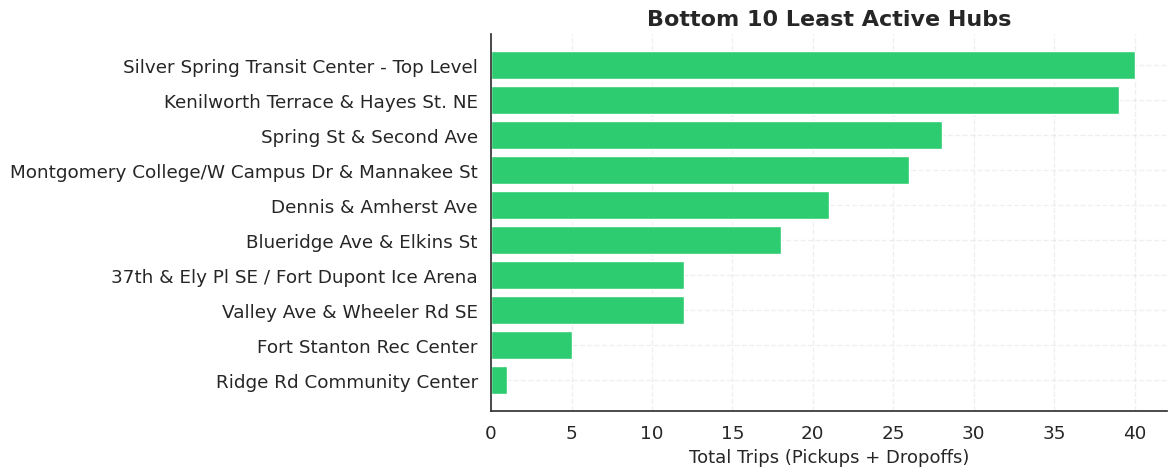

In [29]:
# Bottom 10 Least Active Hubs

bottom_hubs = hub_balance.sort_values('TotalActivity', ascending=True).head(10)

plt.figure(figsize=(12, 5))
plt.barh(bottom_hubs.index, bottom_hubs['TotalActivity'], color='#2ecc71')
plt.title('Bottom 10 Least Active Hubs')
plt.xlabel('Total Trips (Pickups + Dropoffs)')
plt.tight_layout()
plt.show()

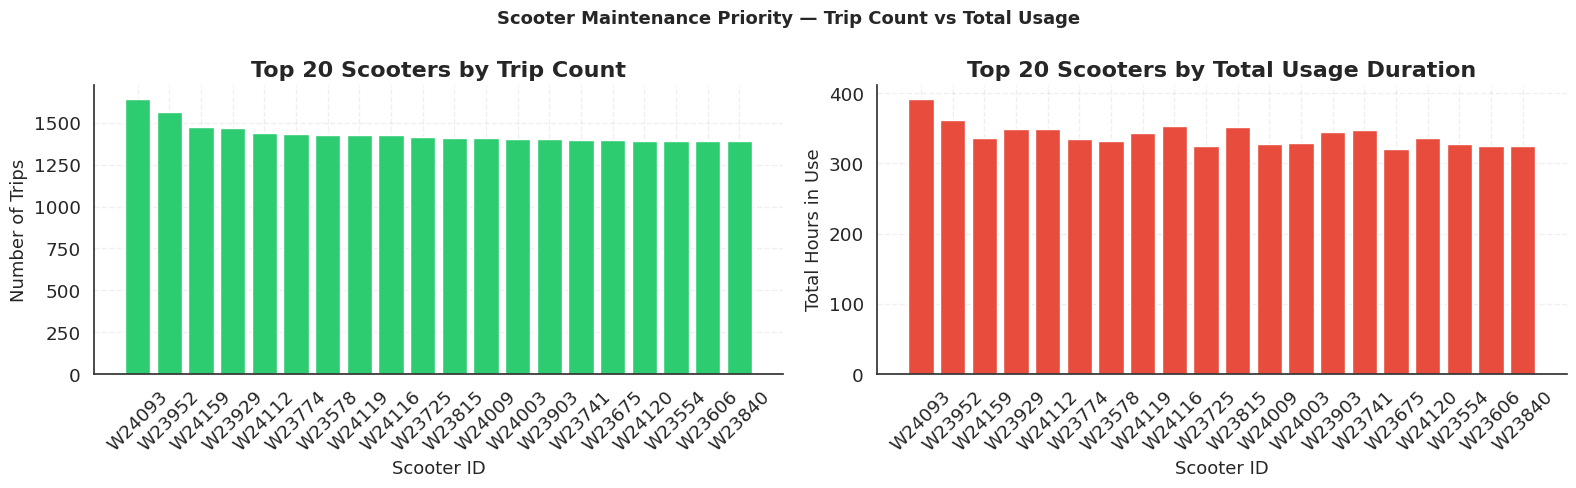

In [28]:
# Top 20 Most Used Scooters — Maintenance Priority

scooter_usage = df.groupby('UnitID').agg(
    TripCount=('UnitID', 'size'),
    TotalDuration=('UsageDuration', 'sum')
).sort_values('TripCount', ascending=False)

top_scooters = scooter_usage.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(top_scooters.index, top_scooters['TripCount'], color='#2ecc71')
axes[0].set_title('Top 20 Scooters by Trip Count')
axes[0].set_xlabel('Scooter ID')
axes[0].set_ylabel('Number of Trips')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(top_scooters.index, top_scooters['TotalDuration'] / 3600, color='#e74c3c')
axes[1].set_title('Top 20 Scooters by Total Usage Duration')
axes[1].set_xlabel('Scooter ID')
axes[1].set_ylabel('Total Hours in Use')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Scooter Maintenance Priority — Trip Count vs Total Usage',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Executive Summary

This analysis examined over 3 million e-scooter trips recorded across a full calendar year (2030)
in a major metropolitan city. The findings below are directly actionable for operations,
pricing, and infrastructure teams.

---

## 1. Fleet Rebalancing — Act Before 7 AM
Hub imbalances follow a predictable commuter pattern. **14th & Irving St** and
**16th & Harvard St** are persistent supply sources, losing 15,869 and 14,675 scooters
net over the year. Five business district hubs — led by **17th & K St / Farragut Square**
(−9,825) — absorb scooters every morning and release them in the evening.
All critical imbalances occur in a **2-hour window between 7–9 AM**, meaning a single
pre-dawn rebalancing run before 7 AM would resolve the majority of daily shortages.

## 2. Time-Based Pricing — Two Clear Windows
Subscriber usage peaks sharply at **8 AM and 17h**, confirming commuter-driven demand.
Activity drops to near-zero between 1–5 AM. This pattern directly supports surge pricing
during peak commute hours and discounted rates overnight to reduce fleet idle time.

## 3. Two User Profiles — Different Needs
Subscribers are commuters: short trips (~650s), weekday-heavy, highly predictable.
Customers are leisure riders: longer trips (~1,500s), more active on weekends and in
summer, with a sharp drop in winter. Marketing and conversion efforts should target
the summer Customer spike when engagement is highest.

## 4. Infrastructure — 10 Hubs Underperforming
Hubs like **Ridge Rd Community Center** and **Fort Stanton Rec Center** recorded
near-zero activity across the entire year. These locations are candidates for
relocation to higher-demand areas.

## 5. Maintenance — W24093 Flagged First
Scooter **W24093** leads both trip count (~1,600 trips) and total usage hours (~400h),
making it the highest maintenance priority. The top 20 scooters by both metrics should
be scheduled for inspection before the next peak season.